### Week 8: Clustering analysis

Instructor: Cornelia Paulik <br>
Email: cilin@ischool.berkeley.edu <br>


Citations: <br>
   - Chapter 11: Python Machine Learning 3rd Edition by [Raschka and Mirjalili](https://sebastianraschka.com), Packt Publishing Ltd. 2019
   - http://shabal.in/visuals/kmeans/5.html
   - https://datasciencelab.wordpress.com/2013/12/12/clustering-with-k-means-in-python/

### Objectives: 
   - k-means clustering.
   - agglomerative hierarchical clustering.
   - density-based spatial clustering (DBSCAN).
   


### Question: 

Why is clustering a useful concept?

Business-oriented applications of clustering:
   - grouping of documents, music, movies by different topics.
   - find customers that share similar interests based on common purchase behaviors as a basis for recommendation engines.

---
### Step 1: Import packages

In [1]:
# standard
import numpy as np
import pandas as pd

# sklearn
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# distances
from scipy.spatial.distance import pdist, squareform

# data visualization
from matplotlib import cm
import matplotlib.pyplot as plt
from IPython.display import Image

# others
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import set_link_color_palette
from scipy.cluster.hierarchy import linkage

---
### Step 2: Create a random 2D dataset
- 150 observations.
- 2 features.
- 3 clusters.

Note that I do not create train and test data!

In [29]:
X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)

In [30]:
# print the first 5 elements in X
print('Head of X:\n', X[:5])

Head of X:
 [[2.60509732 1.22529553]
 [0.5323772  3.31338909]
 [0.802314   4.38196181]
 [0.5285368  4.49723858]
 [2.61858548 0.35769791]]


In [31]:
X.shape

(150, 2)

---
### Step 3: Data visualization 

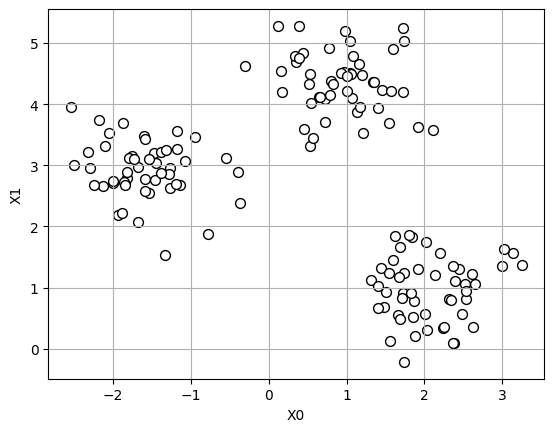

In [32]:
plt.scatter(X[:,0], X[:,1], c='white', marker='o', edgecolor='black', s=50);
plt.xlabel('X0')
plt.ylabel('X1')
plt.grid()

Our goal is to group these examples in X based on their feature similarity. 

----

K-means clustering

----

`` the good news:``
- extremely easy to implement.
- computationally very efficient.
- can be applied to data of any dimension.

`` the bad news:``
- good at identifying clusters with a spherical shape only.
- need to define the number of clusters, *k*, a priori (innapropriate choice can lead to poor clustering performance).
- no clusters can be empty.
- clusters should not overlap.
- the negative effect of the course of dimensionality increases with the number of features in the data

This algo can be summarized as follows:
   - (1) randomly pick *k* centroids from the examples ploted above as initial cluster centers ($\mu^j, j \in {1,...,k}$).
   - (2) assign each example to the **nearest** centroid, $\mu^j$.
   - (3) move the centroids to the center of the examples that were assigned to it.
   - (4) repeat (2-3) until the cluster assignments do not change or a maximum number of iterations is reached.
   
This is a very nice visualization of K-means: http://shabal.in/visuals/kmeans/5.html

``Question:`` How do we know what is the nearest centroid for a given point?

---
### Step 4: Implement K-means

The algorithm is very easy to implement as you can see from steps (1-4) above. You can check an example here: https://datasciencelab.wordpress.com/2013/12/12/clustering-with-k-means-in-python/

So let's focus on understanding the math behind points (2-4) above.

The most commonly used distance measure is the **squared Euclidean distance**.

Given two points x and y:

$d(\mathbf{x,y})^2 = \sum_{f = 1}^{m} (x_f - y_f)^2$, where the index *f* refers to the *f* feature column. 

So based on this distance measure, the optimization problem behind the K-means algorithm minimizes the within-cluster SSE:

$SSE = \sum_{i=1}^{n} \sum_{j=1}^{k} w^{i,j} ||\mathbf{x^i - \mu^j}||_2^2$ 


Note that $\mu^j$ is the representative point (centroid) for cluster *j*, and

$w^{i,j} = \begin{cases}
             1, x^i \in j \\
             0, \text{otherwise}
           \end{cases}$

In [33]:
# create an instance of KMeans class using the scikit-learn package
km = KMeans(n_clusters=3,
           #init='random',
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=1e-04,
           random_state=0)

# predict k-means classes
y_km = km.fit_predict(X)

# print cluster predictions
y_km

array([1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 2, 1,
       2, 2, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 2, 0, 0, 2, 1,
       1, 1, 0, 2, 0, 2, 1, 2, 2, 1, 1, 0, 2, 1, 0, 2, 0, 0, 0, 0, 2, 0,
       2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 0, 0, 2, 1, 1, 2, 2, 1, 1, 1, 0,
       0, 1, 1, 2, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 2,
       0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1], dtype=int32)

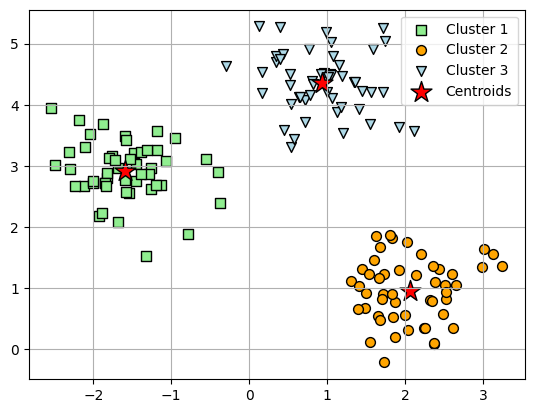

In [34]:
# visualize cluster predictions
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')
plt.scatter(X[y_km == 2, 0],
            X[y_km == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='Cluster 3')
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='Centroids')
plt.legend(scatterpoints=1)
plt.grid()

A note on KMeans class parameters:
   - n_init: runs the k_means algo 10 times independently (with different random centroids); the final model is the one with the lowest SSE.
   - max_iter: maximum number of iterations for each run (if convergence is reached before max_iter, the algo stops).
   - tol: controls the tolerance w.r.t. changes in within-cluster SSE to declare convergence.

``Question:`` What do you think the algorithm does if a cluster is empty?

``Question:`` How are the initial centroids chosen?

you can place the initial centroids far away from each other by setting init='k-means++' in the KMeans() class. This is the recommended setting in practice! Try it on your own on different datasets.

---
### Step 5: Find optimal number of clusters (k)

We cannot use the metrics you have seen so far (examples?) because this is an unsupervised problem, i.e. we don't have information on class labels.

We will need to rely on **intrinsic metrics** to compare the performance of different k-means clusterings:
- elbow method.
- silhoutte plots.

#### Step 5.1 Elbow method

Uses the within-cluster SSE to compare perforamnce of different clusterings. Accessible via the intertia_ attribute after fitting a KMeans model.

print within-cluster SSE for k=3

In [8]:
print('within-cluster SSE: %.2f' % km.inertia_)

within-cluster SSE: 72.48


let's now print within-cluster SSE for k=1,...,10

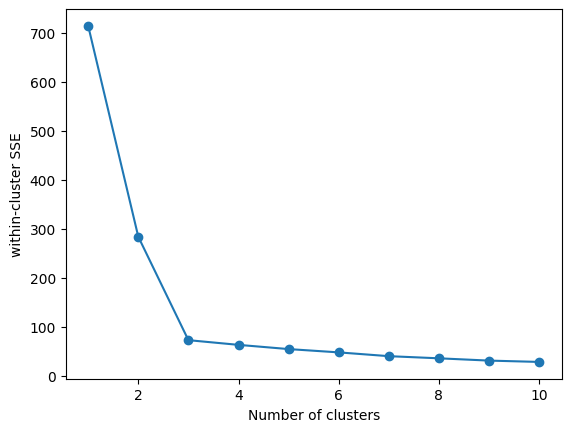

In [9]:
# initialize within-cluster SSE list
wc_SSE = []

# fit KMeans models with different numbers of clusters
for i in range(1, 11):
    km = KMeans(n_clusters=i,           
                init='k-means++',
                n_init=10,
                max_iter=300,
                tol=1e-04,
                random_state=0)
    km.fit(X)
    wc_SSE.append(km.inertia_)
# plot within-cluster SSE for each k
plt.plot(range(1,11), wc_SSE, marker='o');
plt.xlabel('Number of clusters');
plt.ylabel('within-cluster SSE');

We can see that an increase in *k* is associated with a decrease in the within-cluster SSE. 

This is because the examples are closer to the centroid they assigned to.

**The elbow solution**: the optimal *k* is where the within-cluster SSE begings to increase most rapidly.

For this particular example the elbow is at k=3 so we started with a good number of clusters.

#### Step 5.2 Silhoutte plots

A graphical tool to plot a measure of how tightly grouped the examples in the clusters are.

To calculcate the silhoutte coefficient of a single example, apply 3 steps:
- calculate **cluster cohesion**, $a_i$ = average distance between an example, $x_i$, and all other points in the same cluster.
- calculate **cluster separation**, $b_i$, from the next closest cluster = average distance between an example, $x_i$ and all examples in the nearest cluster.
- calculate **the silhouette**, $s_i = \frac{b_i - a_i}{max(b_i,  a_i)}$.


Properties: $s_i \in [-1, 1]$. Ideal value when $s_i$-> 1. Why? (hint: look at the formula).

These being said, let's find the silhouette coefficient for each value in X, using the fitted y_km model above (3 clusters). I will repeat the code here for ease of visualization.

In [38]:
km = KMeans(n_clusters=3,
           #init='random',
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=1e-04,
           random_state=0)

# predict k-means classes
y_km = km.fit_predict(X)

# find silhouette values
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
print('Head of silhouette vals:\n', silhouette_vals[:150])
print('\nMinimum value:', min(silhouette_vals),
      '\nMaximum value:', max(silhouette_vals), '\n')

Head of silhouette vals:
 [0.75956181 0.43233677 0.7747553  0.72286402 0.76729229 0.72280273
 0.69484791 0.76101499 0.77303671 0.67320272 0.62375802 0.40348569
 0.80092777 0.73225118 0.59884632 0.78954087 0.75955598 0.81572606
 0.79897477 0.7936958  0.72221435 0.76384238 0.72671597 0.73219594
 0.74183186 0.81463826 0.76045682 0.62065362 0.57912988 0.76929277
 0.707709   0.8045906  0.7116979  0.78561661 0.66997314 0.65285806
 0.68519649 0.77015391 0.72638012 0.77905009 0.56028722 0.70806176
 0.66201873 0.77669657 0.79206045 0.79499104 0.67874476 0.43073904
 0.72878986 0.75911278 0.61479508 0.68506268 0.76602547 0.80521304
 0.79571018 0.77872478 0.63708395 0.62515462 0.58878683 0.7767243
 0.72889549 0.40154174 0.80287718 0.78189854 0.76687374 0.35466307
 0.79135592 0.56967556 0.37334246 0.54630918 0.61918571 0.70584253
 0.79635805 0.61369253 0.74071059 0.77509834 0.7351302  0.72821908
 0.74135332 0.78854416 0.80090725 0.78961228 0.51299076 0.78719254
 0.71872541 0.6397918  0.78855017 0.7

Clearly, the shilouette coefficients are not even close to 0, and this is an indicator of good clustering.

Let's now plot the silhouettes for each cluster.

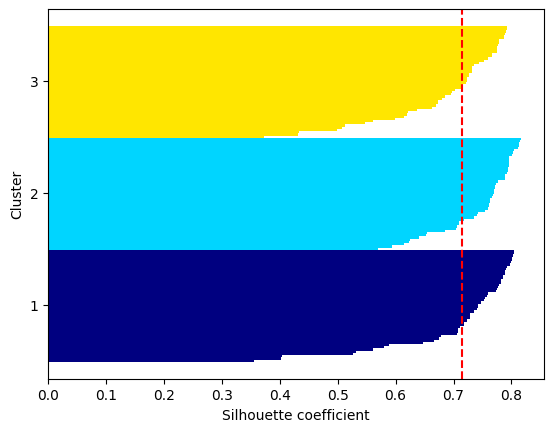

In [39]:
# grab cluster labels and length
cluster_labels = np.unique(y_km)
n_clusters = len(cluster_labels)

y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    # grab silhouette values for each cluster
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    # plot y and x axes
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, 
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
# plot average value across clusters    
silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--") 

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster');
plt.xlabel('Silhouette coefficient');

Clustering models with a high silhouette coefficient are said to be dense, where samples in the same cluster are similar to each other, and well separated, where samples in different clusters are not very similar to each other.

Let's see what the silhouette coefficients look like for bad(!) clustering. Let's try to run the same model with 2 clusters instead of 3.

We will start by visualizing the cluster predictions.

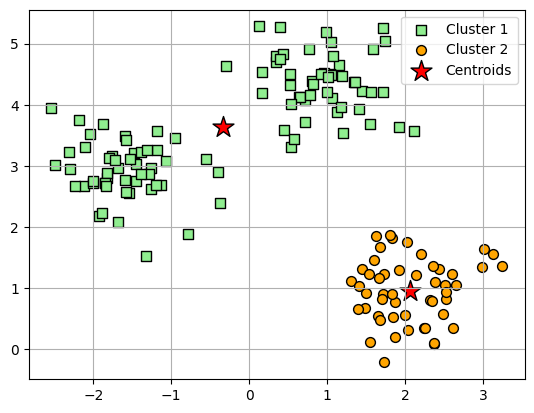

In [40]:
km = KMeans(n_clusters=2,
           #init='random',
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=1e-04,
           random_state=0)

# predict k-means classes
y_km = km.fit_predict(X)

# visualize cluster predictions
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')

plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='Centroids')
plt.legend(scatterpoints=1)
plt.grid()

Clearly, the clustering looks suboptimal. Why? 

Luckily we are in 2D world here so we can plot and visualize the clustering predictions easily, but in real problems this is not the case. So let's look at the silhoutte plots instead.

In [13]:
# find silhouette values
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
print('Head of silhouette vals:\n', silhouette_vals[:30])
print('\nMinimum value:', min(silhouette_vals),
      '\nMaximum value:', max(silhouette_vals), '\n')

Head of silhouette vals:
 [0.7882953  0.38923407 0.52211982 0.55501878 0.78197122 0.39231318
 0.36539069 0.77034967 0.52076799 0.37139396 0.68367198 0.32525645
 0.54324939 0.51018379 0.57910842 0.53478717 0.59821967 0.82440576
 0.55458851 0.80019991 0.52561077 0.79221766 0.39470861 0.48367391
 0.52113582 0.82876127 0.78946442 0.27934914 0.54282261 0.77181097]

Minimum value: -0.001192552976967348 
Maximum value: 0.8287612652107951 



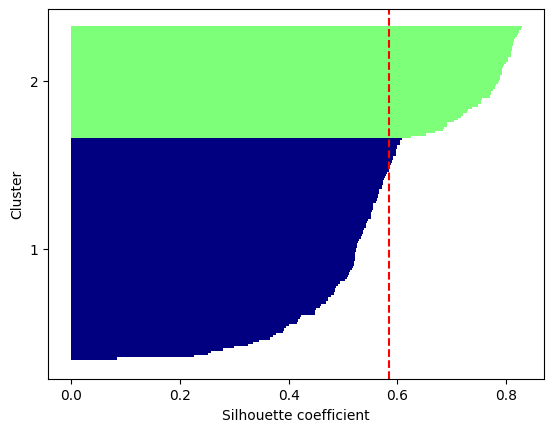

In [14]:
# grab cluster labels and length
cluster_labels = np.unique(y_km)
n_clusters = len(cluster_labels)

y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    # grab silhouette values for each cluster
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    # plot y and x axes
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, 
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
# plot average value across clusters    
silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--") 

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster');
plt.xlabel('Silhouette coefficient');

----

Agglomerative hierarchical clustering

----

`` the good news:``
- no need to specify the number of clusters upfront!
- allows us to plot dendrograms (visualizations of a binary hierarchical clustering)


`` the bad news:``
- the negative effect of the course of dimensionality increases with the number of features in the data

The idea behind agglomerative clusteting is to start with each example in X as an individual cluster and merge the closest pairs of clusters until only one cluster remains.

We can use two types of algorithms for agglomerative hierarchical clustering:
- single linkage
- complete linkage

In single linkage, we compute the distances between the most similar members for each pair of clusters and merge the two clusters for which the distance between the most similar members is smallest.

In complete linkage, instead of comparing the most similar members, we compare the most disimilar members to perform the merge.

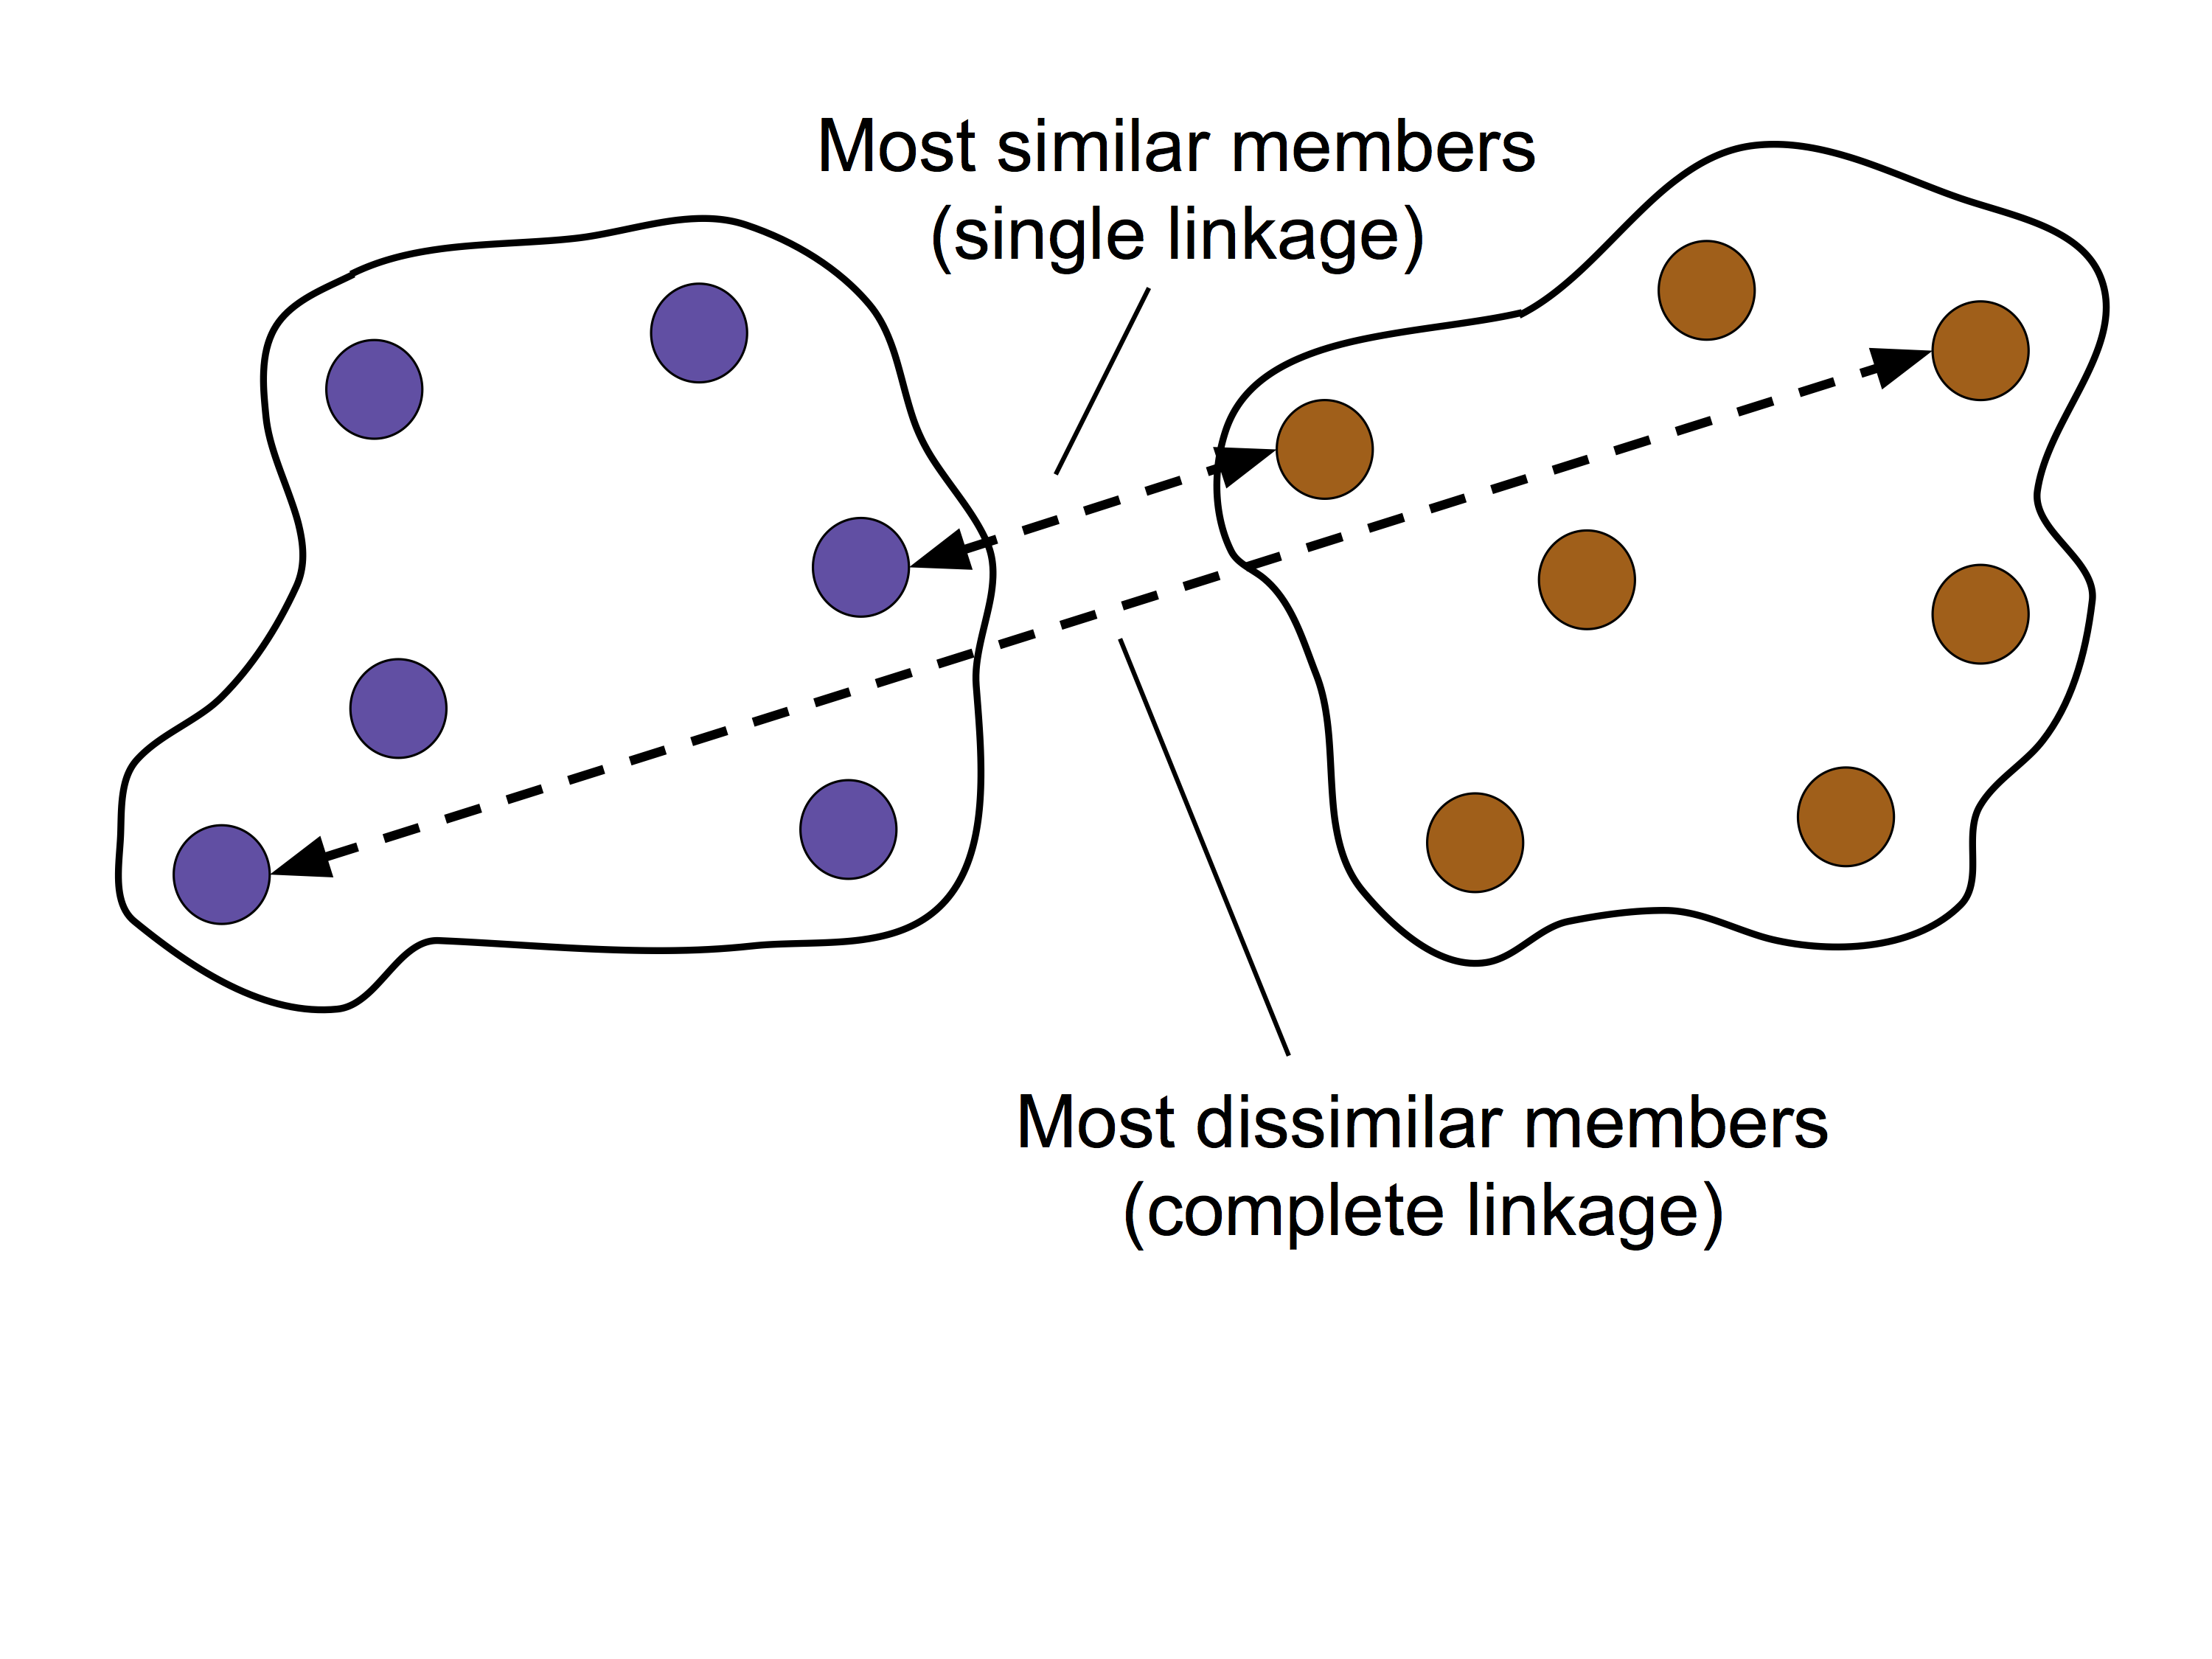

In [15]:
Image(filename='./images/agglomerative_clustering.png', width=300)

Complete linkage - algorithm steps:
- (1) Compute the distance matrix of all examples.
- (2) Represent each data point as a singleton cluster.
- (3) Merge the two closest clusters based on the distance between the most disimilar (distant) members.
- (4) Update the similarity matrix.
- (5) Repeat steps (2-4) until one cluster remains.

---
### Step 6: See agglomerative clustering at work for 5 observations in X

Let's start by computing the distance matrix for all examples. We will only keep the first 5 observations in X for visualization purposes.

In [16]:
# transform X to df
df = pd.DataFrame(X[:5,:])

labels = ["ID_0", "ID_1", "ID_2", "ID_3", "ID_4"]

# calculate the distance between each pair of examples using pdist() from scipy's spatial.distance module
# for visualization: create a symmetrical matrix of pair-wise distances using squareform() from scipy's spatial.distance module
row_dist = pd.DataFrame(squareform(pdist(df, metric='euclidean')),
                        columns=labels,
                        index=labels)
row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,2.942160,3.635185,3.875270,0.867702
ID_1,2.942160,0.000000,1.102140,1.183856,3.617786
ID_2,3.635185,1.102140,0.000000,0.297057,4.415149
ID_3,3.875270,1.183856,0.297057,0.000000,4.637251
ID_4,0.867702,3.617786,4.415149,4.637251,0.000000


Let's now apply the complete linkage algorithm to our clusters (using the scipy.cluster.hierarchy module)

In [17]:
row_clusters = linkage(pdist(df, metric='euclidean'), method='complete')
pd.DataFrame(row_clusters,
             columns=['row label 1', 'row label 2',
                      'distance', 'no. of items in clust.'],
             index=['cluster %d' % (i + 1) 
                    for i in range(row_clusters.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,2.0,3.0,0.297057,2.0
cluster 2,0.0,4.0,0.867702,2.0
cluster 3,1.0,5.0,1.183856,3.0
cluster 4,6.0,7.0,4.637251,5.0


In this matrix, each row represents one merge.  The first and second column denote the most disimilar members (useful for step (3)). The third column represents the distance between those members.

and finally let's plot the dendrograms using the scipy.cluster.hierarchy module

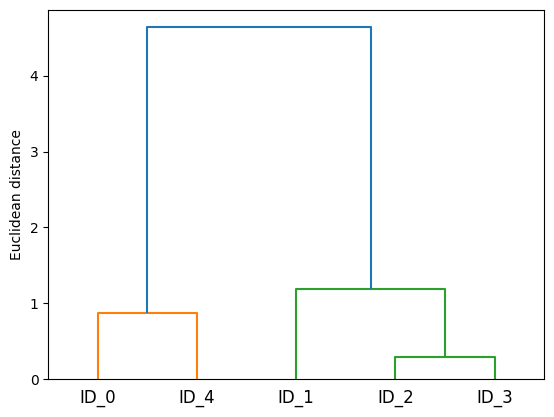

In [18]:
row_dendr = dendrogram(row_clusters, 
                       labels=labels,
                       )
plt.ylabel('Euclidean distance');

The dendrogram summarizes the different clusters that were formed during the agglomerative hierarchical clustering. 
Examples ID2 and ID3 followed by ID0 and ID4 are the most similar one, based on the Euclidian distance metric.

---
### Step 7: Implement agglomerative clustering

Let's fit and visualize predictions for all X, using the AgglomerativeClustering class in scikit-learn.

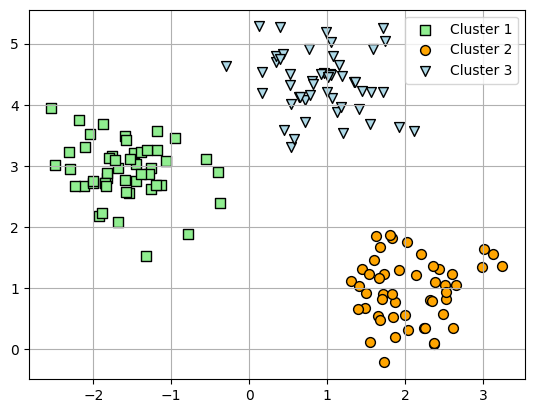

In [19]:
# fit agglomerative clustering
ac = AgglomerativeClustering(n_clusters=3,
                             metric='euclidean',
                             linkage='complete')
y_ac = ac.fit_predict(X)

# visualize cluster predictions
plt.scatter(X[y_ac == 0, 0],
            X[y_ac == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_ac == 1, 0],
            X[y_ac == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')
plt.scatter(X[y_ac == 2, 0],
            X[y_ac == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='Cluster 3')
plt.legend(scatterpoints=1)
plt.grid()

----

Density-based spatial clustering (DBSCAN)

----

`` the good news:``
- good at identifying clusters of all sort of shapes (so not only spherical)
- doesn't necessary assign each point to a cluster (capable of removing noise points)

`` the bad news:``
- the negative effect of the course of dimensionality increases with the number of features in the data
- DBSCAN hyperparameters (MinPts and epsilon) need to be optimized for good clustering results.

The idea is to assign cluster labels based on dense regions of points. 

In DBSCAN the notion of density = number of points within a specified radius, $\epsilon$

DBSCAN - concepts: 

A spacial label is applied to each data point using these criteria:
   - **core point**: if at least a specified number of neighboring points (MinPts) fall within the specified radius $\epsilon$.
   - **border point**: a point that has fewer neighbors than MinPts within $\epsilon$, but lies within an $\epsilon$ radius of a core point.
   - **noise points**: all other points that are neither core nor border points.

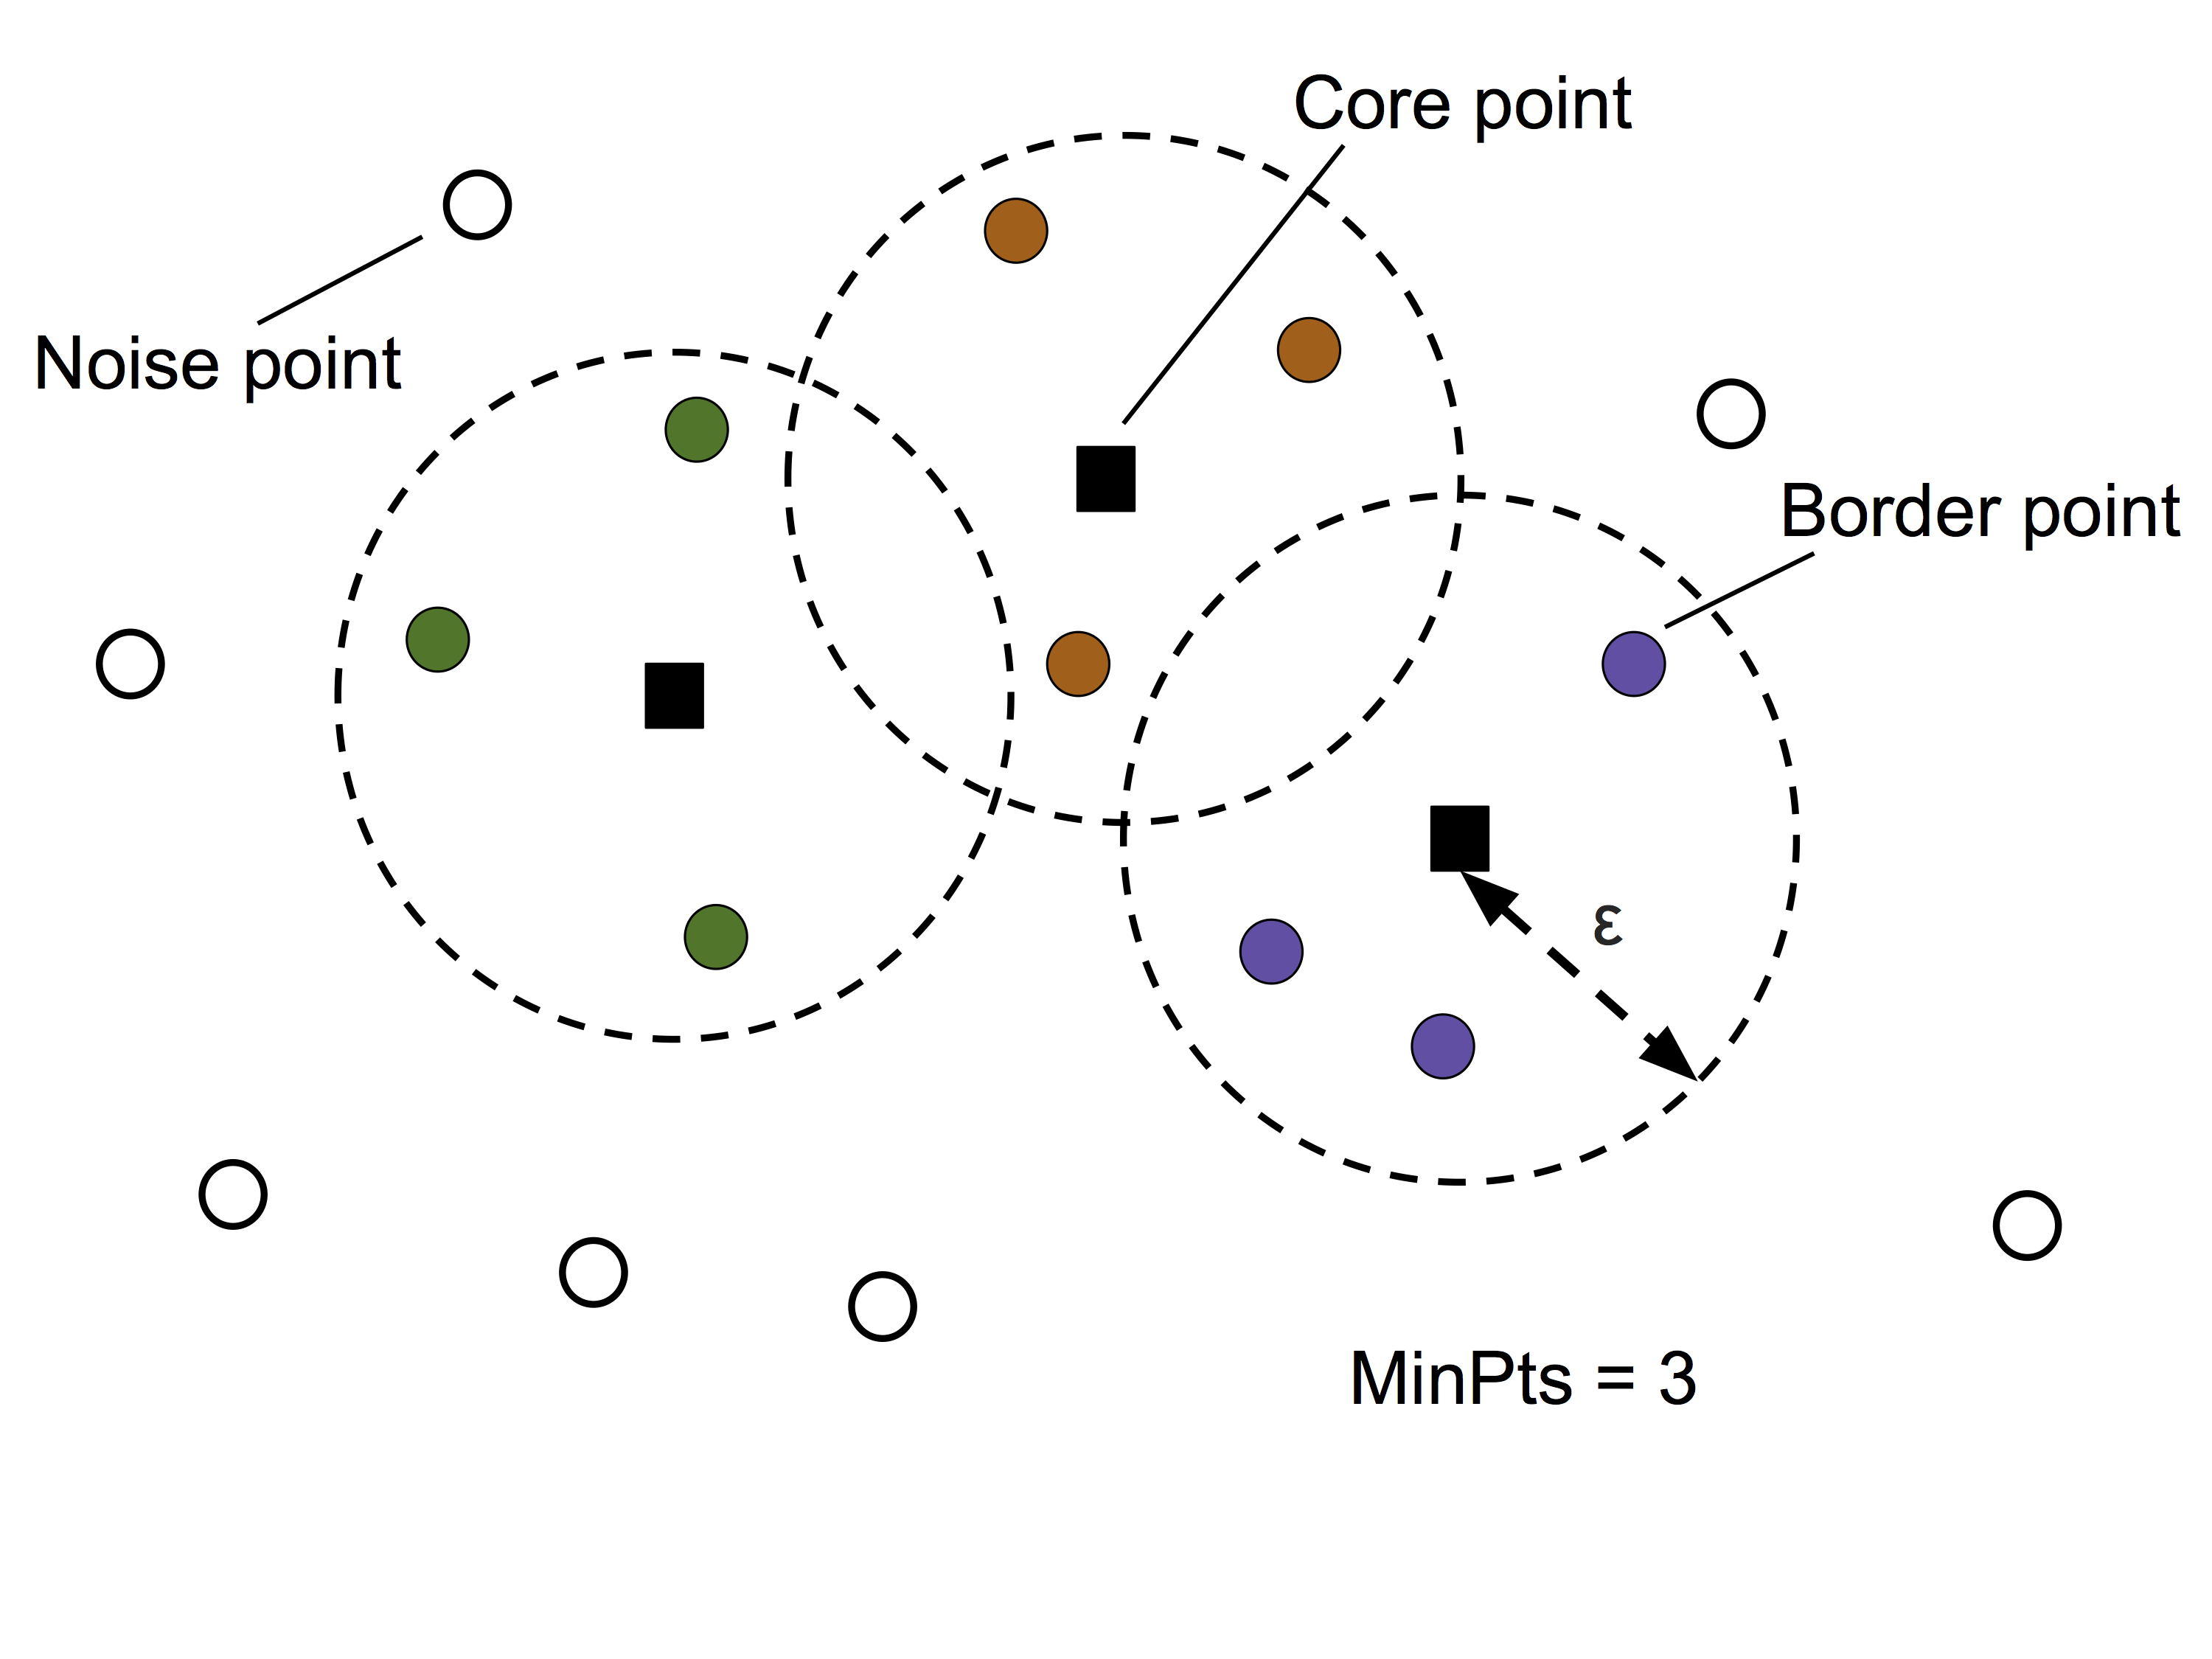

In [20]:
Image(filename='./images/DBSCAN_clustering.png', width=300)

DBSCAN - algorithm:
   - (1) form a separate cluster for each core point or connected group of points (core points are connected if they are not further away from $\epsilon$)
   - (2) assign each border point to the cluster of its corresponding core point.


---
### Step 8: Implement density-based clustering

Let's create a new dataset of non-spherical shapes (let's do half-moon shapes), and then let's compare K-means, hierarchical, and DBSCAN.

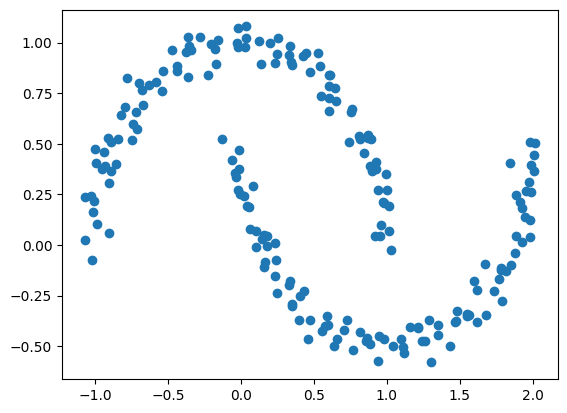

In [41]:
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
plt.scatter(X[:, 0], X[:, 1])

Let's check to see if K-means and Agglomerative clustering can succesfully identify these moon shapes

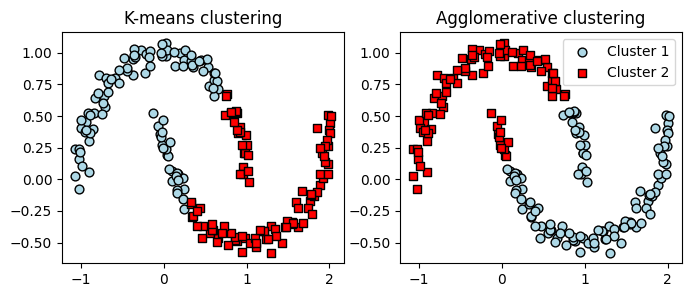

In [22]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# run KMeans clustering
km = KMeans(n_clusters=2, random_state=0)
y_km = km.fit_predict(X)
ax1.scatter(X[y_km == 0, 0], X[y_km == 0, 1],
            edgecolor='black',
            c='lightblue', marker='o', s=40, label='cluster 1')
ax1.scatter(X[y_km == 1, 0], X[y_km == 1, 1],
            edgecolor='black',
            c='red', marker='s', s=40, label='cluster 2')
ax1.set_title('K-means clustering')

# run agglomerative clustering
ac = AgglomerativeClustering(n_clusters=2,
                             metric='euclidean',
                             linkage='complete')
y_ac = ac.fit_predict(X)
ax2.scatter(X[y_ac == 0, 0], X[y_ac == 0, 1], c='lightblue',
            edgecolor='black',
            marker='o', s=40, label='Cluster 1')
ax2.scatter(X[y_ac == 1, 0], X[y_ac == 1, 1], c='red',
            edgecolor='black',
            marker='s', s=40, label='Cluster 2')
ax2.set_title('Agglomerative clustering')

plt.legend();

We can see that none of the two algorithms was able to separate the two clusters.

Finally, let's try DBSCAM to see if it can identify the half-moon-shaped clusters using the density-based approach.

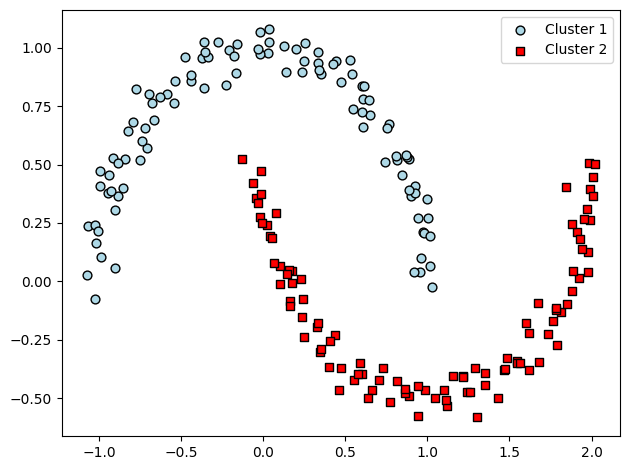

In [23]:
# create DBSCAN instance and fit model
db = DBSCAN(eps=0.2, min_samples=5, metric='euclidean')
y_db = db.fit_predict(X)

# plot labels
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1],
            c='lightblue', marker='o', s=40,
            edgecolor='black', 
            label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1],
            c='red', marker='s', s=40,
            edgecolor='black', 
            label='Cluster 2')
plt.legend()
plt.tight_layout()
#plt.savefig('images/11_16.png', dpi=300)
plt.show()

The DBSCAN algorithm succesfully identified the half moon shapes.

Question: Why?

A few more points:
   - in practice it's not obvious which clustering algorithm will perform best on a given dataset (esp. if it's hard to visualize the data)
   - the chosen distance metric matters a lot!
   - if dealing with the course of dimensionality, it's highly recommended to apply dimensionality reduction before clustering!
   - also, it's very common to compress datasets down to two-dimensional subspaces, which allows for cluster visualization and assign labels using 2D scatterplots.